# 29d. Kubernetes for AI Workloads: HPA & Pod Autoscaling

**Tier:** Production & Safety
**Estimated time:** 50 minutes
**Prerequisites:** 29b (load testing inference), 29c (inference observability)
**Priority:** 🟢 Nice-to-have — infra depth that's usually a platform team's job, but worth understanding once you're the one paged when autoscaling doesn't. *If skipped, revisit when:* you're deciding what metric an inference deployment's autoscaler should watch, or debugging why it scaled too late.
**Source material:** Kubernetes HPA v2 documentation (`autoscaling/v2`, the `desired = ceil(currentReplicas × currentMetricValue / desiredMetricValue)` algorithm and its `behavior.scaleUp`/`scaleDown` stabilization windows); KEDA's event-driven autoscaling model for GPU/queue-depth-based triggers.

## What You'll Learn
- Why the CPU/memory metric Kubernetes' `HorizontalPodAutoscaler` (HPA) scales on **by default** is close to meaningless for GPU-bound LLM inference
- The actual HPA v2 algorithm — `desired = ceil(current × metric / target)` — implemented from scratch, plus why scale-up and scale-down need *different* stabilization behavior
- Why a real autoscaler is *structurally* late for LLM serving: by the time it detects overload, a new pod still needs to pull an image, load multi-gigabyte weights, and warm up before it can take traffic
- What actually fixes that lag, and why "just add a bit more baseline capacity" is a weaker fix than it sounds

## Why This Matters
Notebook 29c built the Gauge metrics (queue depth, active slots) a real autoscaler would watch. This notebook is what happens next: turning that metric into an actual scaling *decision*, and confronting the part every capacity-planning conversation eventually hits — a new GPU pod doesn't appear the instant you ask for it. There's no cluster to autoscale here, so this notebook does the next best thing: real manifests you could apply to one, plus a faithful simulator of the exact control-loop math and timing that makes GPU autoscaling harder than scaling a stateless web tier.


## Why CPU-based HPA fails for LLM inference

The default HPA target is CPU utilization, because for a typical web service, CPU usage tracks load reasonably well. Neither half of that holds for an inference server:

- **The workload is GPU-bound, not CPU-bound.** A vLLM pod can sit at 20% CPU while its GPU is completely saturated — CPU is mostly idle, waiting on the accelerator. Scaling on CPU means the autoscaler is staring at the wrong resource entirely.
- **Request cost varies enormously.** A 10-token classification and a 4,000-token generation hit the same pod utterly differently — nothing like the roughly-uniform request cost that makes "average CPU" a sane proxy for a typical REST API.

The fix real serving stacks converge on: scale on a metric that actually reflects GPU load — **queue depth** or **KV-cache/slot utilization** (exactly the Gauges notebook 29c built) — via HPA v2's `External` metric type backed by a Prometheus adapter, or via **KEDA**, which does the same job with a simpler trigger model built specifically for event/queue-driven scaling.

## The real manifests

These won't run here (no cluster), but they're the actual shape you'd apply to one — and every choice in them reflects a real constraint from earlier notebooks.


In [1]:
import yaml
from pathlib import Path

K8S_DIR = Path("deploy/k8s")
K8S_DIR.mkdir(parents=True, exist_ok=True)

deployment = {
    "apiVersion": "apps/v1",
    "kind": "Deployment",
    "metadata": {"name": "vllm-inference"},
    "spec": {
        "replicas": 2,
        "selector": {"matchLabels": {"app": "vllm-inference"}},
        "template": {
            "metadata": {"labels": {"app": "vllm-inference"}},
            "spec": {
                "containers": [{
                    "name": "vllm",
                    "image": "vllm/vllm-openai:latest",
                    "ports": [{"containerPort": 8000}],
                    "resources": {
                        # nvidia.com/gpu is INTEGER-ONLY -- you cannot request "0.5 GPU"
                        # the way you can request "500m" CPU. A pod gets a whole GPU or none.
                        "requests": {"nvidia.com/gpu": 1, "cpu": "4", "memory": "16Gi"},
                        "limits": {"nvidia.com/gpu": 1, "cpu": "8", "memory": "24Gi"},
                    },
                    "readinessProbe": {
                        # initialDelaySeconds is long on purpose: pulling the image and
                        # loading multi-gigabyte weights genuinely takes this long. A
                        # short delay here just means Kubernetes marks the pod "ready"
                        # (and starts sending it traffic) before it can serve anything.
                        "httpGet": {"path": "/health", "port": 8000},
                        "initialDelaySeconds": 60,
                        "periodSeconds": 10,
                    },
                    "livenessProbe": {
                        "httpGet": {"path": "/health", "port": 8000},
                        "initialDelaySeconds": 90,
                        "periodSeconds": 20,
                    },
                }],
            },
        },
    },
}
(K8S_DIR / "deployment.yaml").write_text(yaml.safe_dump(deployment, sort_keys=False))

service = {
    "apiVersion": "v1",
    "kind": "Service",
    "metadata": {"name": "vllm-inference"},
    "spec": {"selector": {"app": "vllm-inference"}, "ports": [{"port": 80, "targetPort": 8000}]},
}
(K8S_DIR / "service.yaml").write_text(yaml.safe_dump(service, sort_keys=False))

for f in ["deployment.yaml", "service.yaml"]:
    yaml.safe_load((K8S_DIR / f).read_text())
    print(f"{f}: valid YAML")


deployment.yaml: valid YAML
service.yaml: valid YAML


In [2]:
hpa = {
    "apiVersion": "autoscaling/v2",
    "kind": "HorizontalPodAutoscaler",
    "metadata": {"name": "vllm-inference-hpa"},
    "spec": {
        "scaleTargetRef": {"apiVersion": "apps/v1", "kind": "Deployment", "name": "vllm-inference"},
        "minReplicas": 2,
        "maxReplicas": 10,
        "metrics": [{
            # External metric backed by a Prometheus adapter exposing notebook 29c's
            # inference_queue_depth Gauge -- NOT CPU. AverageValue means "per pod":
            # HPA divides the raw metric by replica count for you before comparing to target.
            "type": "External",
            "external": {
                "metric": {"name": "inference_queue_depth"},
                "target": {"type": "AverageValue", "averageValue": "4"},
            },
        }],
        "behavior": {
            # Scale up immediately when overloaded; scale down only after 5 minutes of
            # sustained lower load, so a brief dip doesn't strip capacity you'll need
            # again a minute later. This exact asymmetry is what the simulator below
            # implements and tests.
            "scaleUp": {"stabilizationWindowSeconds": 0},
            "scaleDown": {"stabilizationWindowSeconds": 300},
        },
    },
}
(K8S_DIR / "hpa.yaml").write_text(yaml.safe_dump(hpa, sort_keys=False))
yaml.safe_load((K8S_DIR / "hpa.yaml").read_text())
print("hpa.yaml: valid YAML")
print(f"\nReal-world equivalent: a KEDA ScaledObject would express the same intent")
print(f"(scale on a queue-depth trigger) with less YAML and no separate Prometheus")
print(f"adapter -- KEDA ships the trigger types (Prometheus, Redis, SQS, ...) built in.")


hpa.yaml: valid YAML

Real-world equivalent: a KEDA ScaledObject would express the same intent
(scale on a queue-depth trigger) with less YAML and no separate Prometheus
adapter -- KEDA ships the trigger types (Prometheus, Redis, SQS, ...) built in.


## The HPA algorithm, from scratch

Kubernetes' actual formula is refreshingly simple: `desired = ceil(currentReplicas × currentMetricValue / desiredMetricValue)`. Everything else — probes, stabilization windows, the whole rest of this notebook — is about making that one line survive contact with a metric that takes minutes to respond to, not seconds.


In [3]:
import math

def hpa_desired_replicas(current_replicas, current_metric_value, target_metric_value, min_replicas, max_replicas):
    """The real HPA v2 formula. current_metric_value here is the TOTAL (not per-pod)
    metric -- e.g. total queue depth across all pods -- matching how an External metric
    of type AverageValue is computed: HPA divides by current_replicas internally.
    """
    per_pod = current_metric_value / max(1, current_replicas)
    desired = math.ceil(current_replicas * per_pod / target_metric_value)
    return max(min_replicas, min(max_replicas, desired))

# Sanity check: 40 total queue depth across 4 pods = 10/pod; target is 4/pod -> need 10 pods.
print(hpa_desired_replicas(current_replicas=4, current_metric_value=40, target_metric_value=4,
                           min_replicas=2, max_replicas=10))


10


## Simulating a real traffic ramp against this loop

A fluid-queue model: at every simulated second, incoming requests either get served by current capacity or add to a queue. Every 15 seconds (Kubernetes' real HPA sync period), the control loop above runs and may request more replicas — which take **90 simulated seconds** to become ready, standing in for image pull + weight load + KV-cache warmup.


In [4]:
import numpy as np

DT = 1.0
DURATION = 420                    # 7 simulated minutes
PER_REPLICA_CAPACITY = 5.0        # req/s one pod can sustain
MAX_REPLICAS = 10
TARGET_QUEUE_PER_REPLICA = 4.0
SYNC_PERIOD = 15                  # HPA's real default control-loop interval
POD_STARTUP_DELAY = 90            # seconds for a new pod to become ready

def traffic_ramp(t):
    """8 req/s baseline, ramping to 45 req/s over 4 minutes, then holding."""
    if t < 60:
        return 8
    elif t < 300:
        return 8 + (45 - 8) * (t - 60) / 240
    else:
        return 45

def simulate(min_replicas=2, use_stabilization=True, stabilization_s=300, pod_startup_delay=POD_STARTUP_DELAY):
    # use_stabilization defaults to True because real K8s HPA always applies SOME
    # scale-down stabilization (300s by default) -- it isn't an optional extra.
    queue_depth = 0.0
    ready_replicas = min_replicas
    pending_pods = []            # (ready_time, count) for pods still starting up
    recommendation_history = []   # (time, desired) for the stabilization window
    queue_trace, replica_trace = [], []

    for step in range(int(DURATION / DT)):
        t = step * DT
        arrivals = traffic_ramp(t)

        still_pending = []
        for ready_time, count in pending_pods:
            if t >= ready_time:
                ready_replicas += count
            else:
                still_pending.append((ready_time, count))
        pending_pods = still_pending

        capacity = ready_replicas * PER_REPLICA_CAPACITY
        queue_depth = max(0.0, queue_depth + (arrivals - capacity) * DT)
        queue_trace.append(queue_depth)
        replica_trace.append(ready_replicas)

        if step % int(SYNC_PERIOD / DT) == 0:
            current_total = ready_replicas + sum(c for _, c in pending_pods)
            desired = hpa_desired_replicas(current_total, queue_depth, TARGET_QUEUE_PER_REPLICA,
                                            min_replicas, MAX_REPLICAS)
            recommendation_history.append((t, desired))

            if use_stabilization and desired < current_total:
                window_start = t - stabilization_s
                windowed = [d for (rt, d) in recommendation_history if rt >= window_start]
                desired = max(windowed)   # scale down only to the WORST-case recent need

            if desired > current_total:
                pending_pods.append((t + pod_startup_delay, desired - current_total))
            elif desired < current_total:
                ready_replicas = desired   # scaling down is instant; removing pods isn't slow

    return np.array(queue_trace), np.array(replica_trace)

queue_trace, replica_trace = simulate(min_replicas=2)
print(f"Peak queue depth: {queue_trace.max():.0f}")
print(f"Replicas at t=0,90,180,270,360: {replica_trace[[0,90,180,270,360]]}")


Peak queue depth: 875
Replicas at t=0,90,180,270,360: [ 2  2  6 10 10]


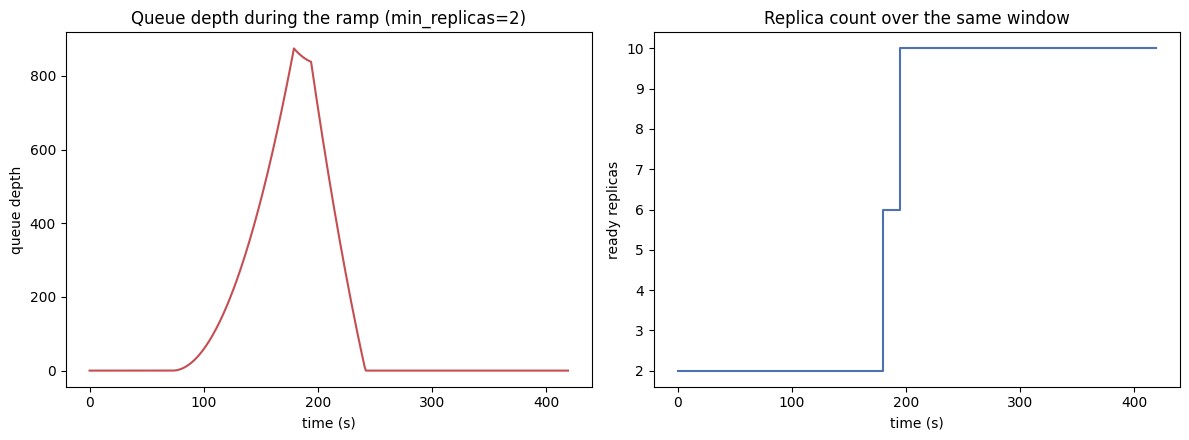

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
t_axis = np.arange(len(queue_trace))

ax1.plot(t_axis, queue_trace, color="#C44E52")
ax1.set_xlabel("time (s)"); ax1.set_ylabel("queue depth")
ax1.set_title("Queue depth during the ramp (min_replicas=2)")

ax2.plot(t_axis, replica_trace, color="#4C72B0", drawstyle="steps-post")
ax2.set_xlabel("time (s)"); ax2.set_ylabel("ready replicas")
ax2.set_title("Replica count over the same window")
plt.tight_layout(); plt.show()


*Load starts exceeding the 2-replica baseline's 10 req/s capacity around t=90s. The HPA control loop notices within one sync period and requests more pods — but they take 90 seconds to become ready, so the queue keeps growing the entire time new pods are still starting up. By the time capacity actually catches up (replicas fully at 10 around t≈210s), a real user's request could have been queued for minutes. This is the structural gap CPU-based autoscaling can't paper over either — the lag is about pod startup time, not which metric triggered the scale-up.*

## Does more baseline capacity fix it?

The obvious fix is "keep more replicas warm so you don't need the reactive path as often." Let's actually test that instead of assuming it.


In [6]:
for min_r in [2, 4, 9]:
    q, r = simulate(min_replicas=min_r)
    print(f"min_replicas={min_r:2d}  peak queue depth: {q.max():8.1f}")


min_replicas= 2  peak queue depth:    874.7
min_replicas= 4  peak queue depth:   1049.1
min_replicas= 9  peak queue depth:      0.0


That's not a clean "more is better" curve — `min_replicas=4` is actually *worse* than `min_replicas=2` here. The reason is the HPA formula itself: a higher baseline replica count means the *same* raw queue depth divides into a smaller per-pod value, so the control loop takes longer to conclude "this needs more capacity" — a partial cushion buys you a later collision with the same wall, not a smaller one. Only `min_replicas=9` — provisioned close to the *actual peak* (45 req/s ÷ 5 req/s/pod = 9) — avoids the reactive path altogether and shows zero queue buildup.

The real lesson: **overprovisioning only works if it's sized to the peak you're protecting against.** A little extra baseline capacity interacts with the autoscaler's own math in ways that can make the reactive gap *later and just as bad*, not smaller. If you know your peak, provision for it; if you don't, the fix is a faster reactive path (a lower target, a shorter sync assumption in your capacity math), not an arbitrary buffer.

## Exercises


In [7]:
# Exercise 1 (Warm-up): How much does pod startup time matter?
# Task: Re-run simulate(min_replicas=2) with POD_STARTUP_DELAY reduced to 30 (rewrite the
#       function's default or pass it as a new parameter) and separately with it raised to
#       180. Print peak queue depth for both. Is the relationship linear, worse, or better
#       than linear?
# Hint: You'll need to add pod_startup_delay as a parameter to simulate() and use it in
#       place of the POD_STARTUP_DELAY global inside the function body.

# YOUR CODE HERE


In [8]:
# Exercise 2 (Apply): Show scale-down stabilization actually preventing flapping
# Task: simulate() already accepts use_stabilization and stabilization_s, but the teaching
#       demo above never exercised the scale-DOWN path (the ramp only goes up). Extend
#       traffic_ramp into a longer function that ramps up to 45, HOLDS, then drops to 20,
#       then rises back to 45 (a dip-and-recover shape). Run the resulting simulation with
#       use_stabilization=False and again with True, and print the replica trace every 30s
#       for both. Count how many times the replica count CHANGES in each run -- confirm
#       stabilization produces meaningfully fewer changes (less flapping), even though
#       neither run is perfectly flap-free.
# Hint: def ramp_with_dip(t): return traffic_ramp(t) if t < 420 else (20 if t < 570 else 45)
#       -- then pass this as the traffic function (you'll need to parameterize simulate()
#       to accept a traffic_fn argument instead of always calling traffic_ramp directly).

# YOUR CODE HERE


In [9]:
# Exercise 3 (Extend): Which Prometheus metric type actually belongs in the HPA?
# Task: Notebook 29c built three metric types for the mock server: Counter
#       (inference_requests_total, inference_tokens_total), Histogram (TTFT, E2E), and
#       Gauge (inference_queue_depth, inference_active_slots). The HPA manifest above
#       scales on an External metric backed by inference_queue_depth. In a comment, explain
#       why a Counter or a Histogram would be the WRONG choice to back an HPA External
#       metric directly -- be specific about what a Counter's raw value means over time,
#       and what a Histogram bucket count would even represent as a "current" scaling
#       signal. Then compute inference_active_slots / (BATCH_SLOTS * current_replicas) as
#       an alternative "utilization" metric using this notebook's variables, and describe
#       one scenario where scaling on utilization would react LATER than scaling on queue
#       depth (hint: what's utilization while requests are already queued but no slot has
#       freed up yet?).

# YOUR CODE HERE


<details>
<summary>Show solutions</summary>

```python
# Exercise 1
for delay in [30, 90, 180]:
    q, r = simulate(min_replicas=2, pod_startup_delay=delay)
    print(f"pod_startup_delay={delay:3d}s  peak queue depth: {q.max():8.1f}")
# Peak queue depth grows FASTER than linear in startup delay: 30s -> 30s->90s is 3x the
# delay for ~5x the peak queue, and 90s->180s is 2x the delay for ~3.6x the peak queue. A
# longer delay doesn't just mean "the same overload for longer" -- the queue keeps
# accumulating at the same excess rate for a longer stretch, AND that excess rate itself
# grows because the ramp keeps climbing the whole time new pods are still starting up.
# Cutting cold-start time (pre-pulled images, cached weights) pays off more than
# proportionally.

# Exercise 2
def ramp_with_dip(t):
    if t < 420:
        return traffic_ramp(t)
    elif t < 570:
        return 20
    else:
        return 45

def simulate_flexible(traffic_fn, duration, min_replicas=2, use_stabilization=False, stabilization_s=300):
    queue_depth = 0.0
    ready_replicas = min_replicas
    pending_pods = []
    recommendation_history = []
    replica_trace = []
    for step in range(int(duration / DT)):
        t = step * DT
        arrivals = traffic_fn(t)
        still_pending = []
        for ready_time, count in pending_pods:
            if t >= ready_time:
                ready_replicas += count
            else:
                still_pending.append((ready_time, count))
        pending_pods = still_pending
        capacity = ready_replicas * PER_REPLICA_CAPACITY
        queue_depth = max(0.0, queue_depth + (arrivals - capacity) * DT)
        replica_trace.append(ready_replicas)
        if step % int(SYNC_PERIOD / DT) == 0:
            current_total = ready_replicas + sum(c for _, c in pending_pods)
            desired = hpa_desired_replicas(current_total, queue_depth, TARGET_QUEUE_PER_REPLICA,
                                            min_replicas, MAX_REPLICAS)
            recommendation_history.append((t, desired))
            if use_stabilization and desired < current_total:
                window_start = t - stabilization_s
                windowed = [d for (rt, d) in recommendation_history if rt >= window_start]
                desired = max(windowed)
            if desired > current_total:
                pending_pods.append((t + POD_STARTUP_DELAY, desired - current_total))
            elif desired < current_total:
                ready_replicas = desired
    return np.array(replica_trace)

DIP_DURATION = 750
for label, stab in [("without stabilization", False), ("with stabilization", True)]:
    r = simulate_flexible(ramp_with_dip, DIP_DURATION, use_stabilization=stab)
    changes = int(np.sum(np.diff(r) != 0))
    print(f"{label}: {changes} replica-count changes over {DIP_DURATION}s, "
          f"trace@30s = {r[::30]}")
# Stabilization doesn't eliminate every transition, but it substantially reduces how often
# the replica count actually flips -- each scale-down has to survive a 5-minute look-back
# at the worst recent recommendation, so a brief dip in load doesn't trigger a scale-down
# that gets immediately reversed a minute later.

# Exercise 3
# A Counter's raw value only ever increases -- "1,600 total requests" says nothing about
# CURRENT load; you'd have to compute rate() first, which needs two scrapes and adds lag
# an HPA control loop (already slow) can't afford. A Histogram's bucket counts are
# CUMULATIVE totals too (same problem as a Counter) and describe a latency DISTRIBUTION,
# not a point-in-time signal of how much MORE capacity is needed right now -- you'd have to
# convert it to a rate AND pick a percentile AND decide what latency threshold means
# "scale up," several steps removed from a direct capacity signal. A Gauge is the only type
# that reports current state directly, which is what a scaling decision needs.
#
# BATCH_SLOTS = 16  # from notebook 29c's mock server
# utilization = lambda active_slots, current_replicas: active_slots / (BATCH_SLOTS * current_replicas)
#
# Utilization reacts LATER than queue depth in exactly the moment that matters most: the
# instant every slot is already full and NEW requests start queueing, utilization is
# already at its ceiling (100%) and CANNOT rise any further to signal "it's getting worse" --
# it's pinned at 1.0 whether there are 5 requests waiting or 5,000. Queue depth keeps
# climbing and keeps giving the autoscaler a proportional signal of how much MORE capacity
# is needed, exactly when utilization has nothing further to say.
```
</details>


## Key Takeaways
- CPU/memory autoscaling is the wrong tool for GPU-bound inference: the GPU is the bottleneck resource, and request cost varies far more than a typical web service's, so **queue depth or slot utilization** (Gauges, notebook 29c) is the metric that actually reflects load.
- The HPA v2 algorithm itself is simple — `desired = ceil(current × metric / target)` — implemented in a few lines here; almost all of the real-world complexity is in making that formula survive a metric pipeline and a slow reactive path.
- **Pod startup time, not the scaling metric, is the structural bottleneck** for GPU autoscaling: a new pod pulling an image and loading weights can take minutes, during which the queue keeps growing regardless of how fast the autoscaler reacted.
- **Scale-up and scale-down need different stabilization**: react fast to overload, but require sustained low load (a real K8s default of 5 minutes, using the *maximum* recent recommendation) before removing capacity — otherwise a brief dip causes a scale-down that gets reversed a minute later, paying the startup-delay penalty all over again.
- Overprovisioning baseline capacity only helps when it's sized to the **actual peak** — a partial buffer can interact with the autoscaler's own per-replica math to delay the same collision rather than shrinking it.

## What's Next
Notebook **32c — Gateway Routing & Unit Economics** moves from *provisioning enough capacity* to *routing each request to the right capacity* — a cost/latency/quality-aware router that decides, per request, which model and which backend should serve it.
